<a href="https://colab.research.google.com/github/Mohamed-Hesham-Latif/ML-55-25005/blob/main/Classification_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Exploratory Data Analysis (EDA)

In this section, we explore the car crash dataset to better understand its structure, identify missing values, and analyze the distribution of features. This step helps in preparing the data for machine learning models and gaining insights into factors affecting crash severity.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [33]:
train = pd.read_csv("car_crash_train.csv", keep_default_na=False)

# Preview data
train.head()

,Crash Speed (km/h),Impact Angle (degrees),Airbag Deployed,Seatbelt Used,Weather Conditions,Road Conditions,Crash Type,Vehicle Type,Vehicle Age (years),Brake Condition,Tire Condition,Driver Age,Driver Experience (years),Alcohol Level (BAC%),Distraction Level,Time of Day,Traffic Density,Visibility Distance (m),Severity
0,182,69,Yes,No,Clear,Dry,Rollover,Sedan,5,Good,Good,23,11,0.025314,None,Morning,Low,213,Minor Injury
1,192,73,Yes,No,Clear,Dry,Head-on,Truck,3,Good,Good,29,27,0.002372,Phone,Morning,Medium,426,Minor Injury
2,114,77,No,Yes,Clear,Dry,Head-on,Sedan,16,Good,Worn out,73,45,0.000483,None,Morning,Medium,175,Minor Injury
3,93,14,No,Yes,Clear,Dry,Rear-end,Truck,14,Worn out,Worn out,27,18,0.176578,None,Afternoon,Medium,82,Minor Injury
4,170,96,No,Yes,Clear,Dry,Side impact,SUV,15,Good,Good,70,27,0.065696,Other,Morning,Medium,96,Severe Injury


In [66]:
# Display the number of rows and columns in the training dataset
train.shape

(4000, 19)

In [67]:
# Display basic information about the training dataset,
# including column names, data types, non-null values, and memory usage
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Crash Speed (km/h)         4000 non-null   int64  
 1   Impact Angle (degrees)     4000 non-null   int64  
 2   Airbag Deployed            4000 non-null   object 
 3   Seatbelt Used              4000 non-null   object 
 4   Weather Conditions         4000 non-null   object 
 5   Road Conditions            4000 non-null   object 
 6   Crash Type                 4000 non-null   object 
 7   Vehicle Type               4000 non-null   object 
 8   Vehicle Age (years)        4000 non-null   int64  
 9   Brake Condition            4000 non-null   object 
 10  Tire Condition             4000 non-null   object 
 11  Driver Age                 4000 non-null   int64  
 12  Driver Experience (years)  4000 non-null   int64  
 13  Alcohol Level (BAC%)       4000 non-null   float

In [68]:
# Generate summary statistics for the numerical columns in the training dataset,
# such as count, mean, standard deviation, minimum, maximum, and quartile values
train.describe()

,Crash Speed (km/h),Impact Angle (degrees),Vehicle Age (years),Driver Age,Driver Experience (years),Alcohol Level (BAC%),Visibility Distance (m)
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,110.999750,89.979750,9.445500,48.698750,24.723000,0.101216,247.583500
std,52.227839,51.301514,5.718147,17.815972,14.211818,0.057820,143.478155
min,20.000000,0.000000,0.000000,18.000000,0.000000,0.000054,10.000000
25%,66.000000,45.000000,5.000000,34.000000,13.000000,0.050630,120.000000
50%,112.000000,89.500000,9.000000,49.000000,25.000000,0.101574,244.000000
75%,157.000000,134.000000,14.000000,64.000000,37.000000,0.151783,372.000000
max,199.000000,179.000000,19.000000,79.000000,49.000000,0.199936,499.000000


In [69]:
# Count the number of missing values in each column of the training dataset
# and sort the columns from the highest number of missing values to the lowest
train.isnull().sum().sort_values(ascending=False)

,0
Crash Speed (km/h),0
Impact Angle (degrees),0
Airbag Deployed,0
Seatbelt Used,0
Weather Conditions,0
Road Conditions,0
Crash Type,0
Vehicle Type,0
Vehicle Age (years),0
Brake Condition,0


### Missing Values Analysis

From the analysis, we observe that the dataset does not contain any actual missing, blank, or empty values. The Distraction Level feature includes the value "None", which represents a valid category meaning that no distraction was recorded. Therefore, it should not be treated as a missing value. All features are complete, and no missing-value imputation is required for this column.

In [70]:
# Select the target column as the last column in the training dataset
target_col = train.columns[-1]

# Count how many samples belong to each class in the target column
train[target_col].value_counts()

,count
Severity,
Minor Injury,2756
Severe Injury,1038
Fatal,206


### Target Variable Analysis

The target variable **Severity** is not evenly distributed across classes. Most cases fall under *Minor Injury*, followed by *Severe Injury*, while *Fatal* cases are significantly fewer.

This indicates that the dataset is **imbalanced**, which may affect the performance of some machine learning models.

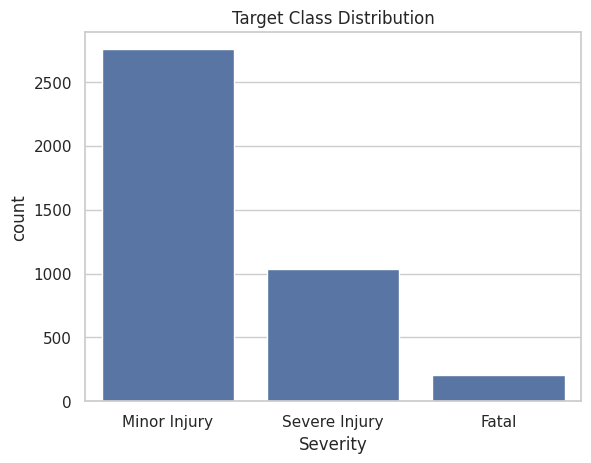

In [71]:
# Plot the distribution of the target classes to visualize class imbalance
sns.countplot(x=train[target_col])

# Add a title to the plot
plt.title("Target Class Distribution")

# Display the plot
plt.show()

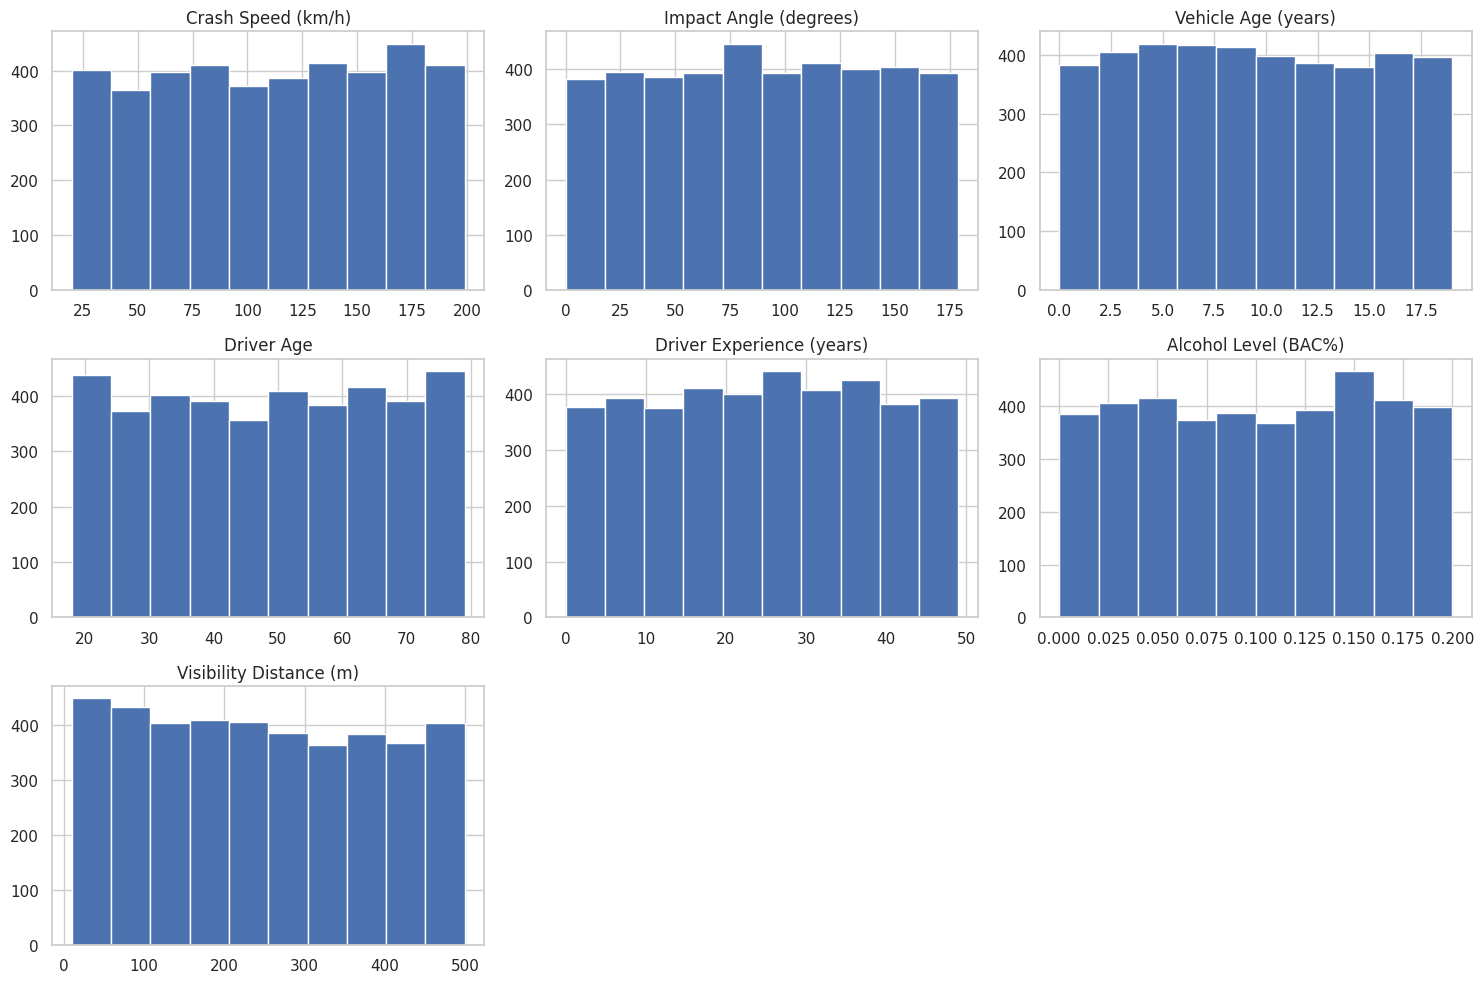

In [72]:
# Select all numerical columns from the training dataset
numerical_cols = train.select_dtypes(include=np.number).columns

# Plot histograms for all numerical columns to understand their distributions
train[numerical_cols].hist(figsize=(15, 10))

# Adjust the layout so that the plots do not overlap
plt.tight_layout()

# Display the histograms
plt.show()

### Numerical Features Distribution

The numerical features such as crash speed, impact angle, vehicle age, driver age, and visibility distance appear to be relatively evenly distributed without extreme skewness.

There are no obvious extreme outliers in most features, and the values are spread across reasonable ranges.

This suggests that the dataset is fairly well-behaved and may not require heavy transformation.

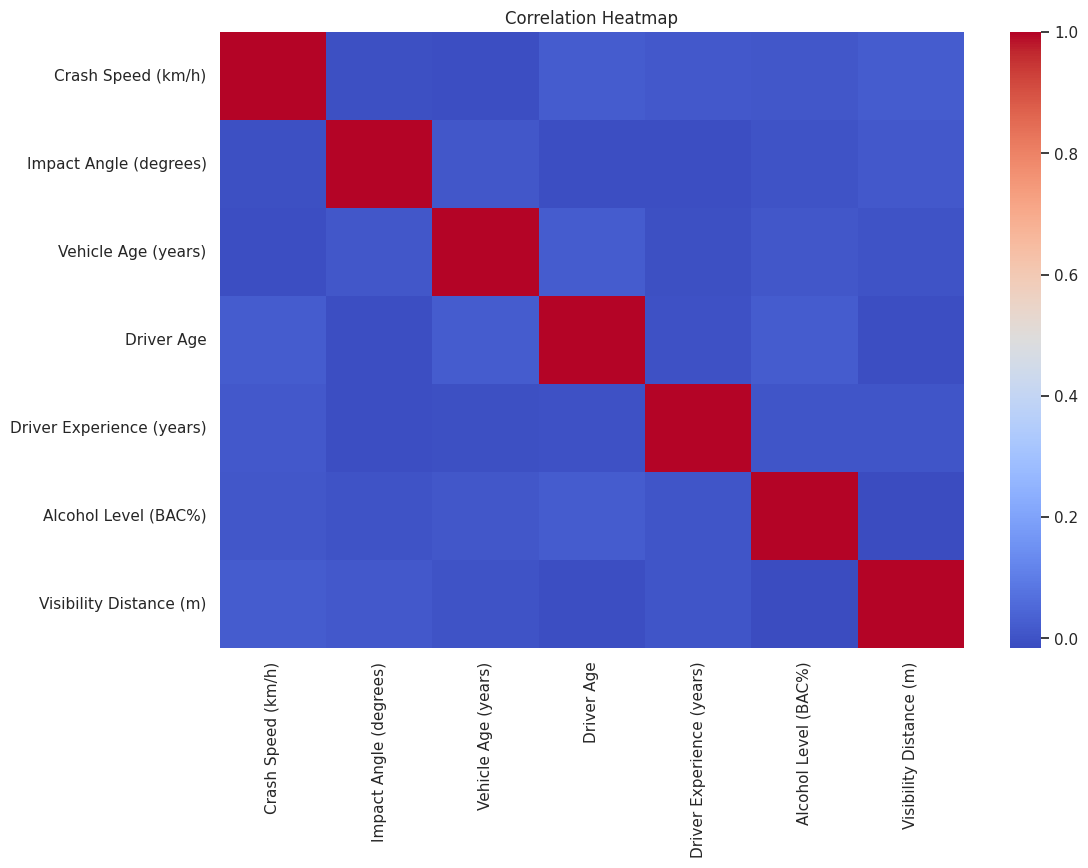

In [73]:
# Create a new figure with a larger size for better readability
plt.figure(figsize=(12, 8))

# Plot a correlation heatmap for the numerical columns
# This shows the relationship between numerical features
sns.heatmap(train[numerical_cols].corr(), cmap='coolwarm')

# Add a title to the heatmap
plt.title("Correlation Heatmap")

# Display the heatmap
plt.show()

### Correlation Analysis

From the correlation heatmap, we observe that there are no strong correlations between the numerical features.

Most feature pairs show very low correlation values, indicating that the features are relatively independent of each other.

This suggests that multicollinearity is not a major issue in this dataset, and all features can be considered useful for model training.

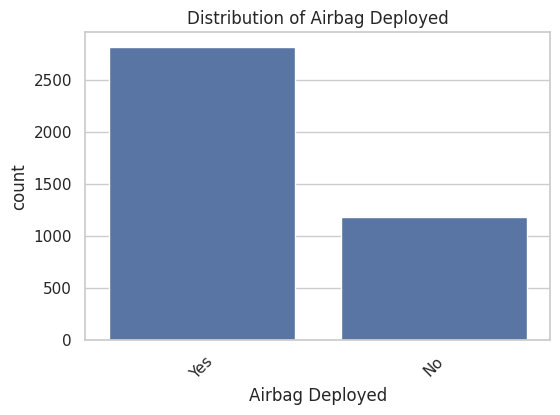

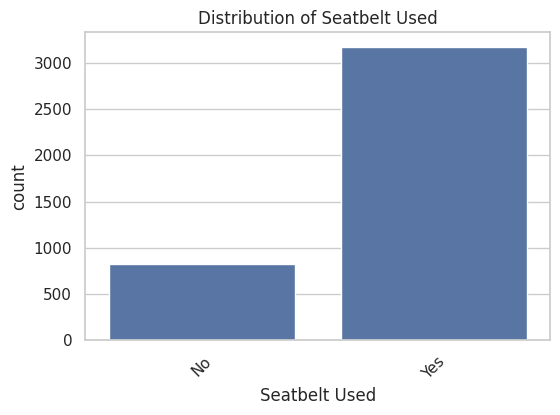

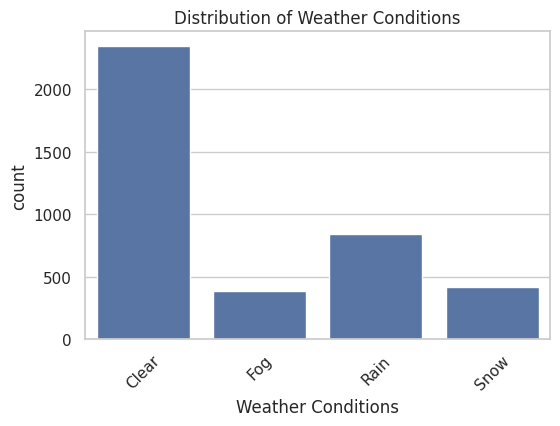

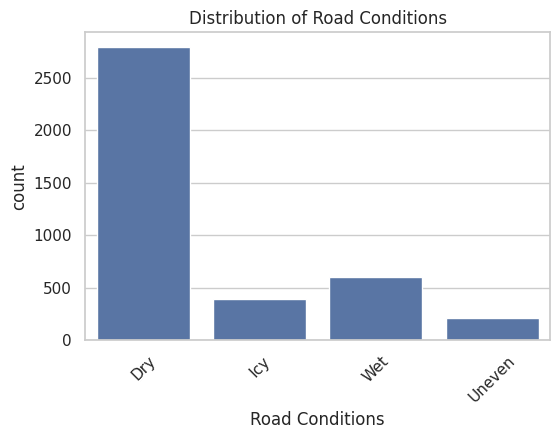

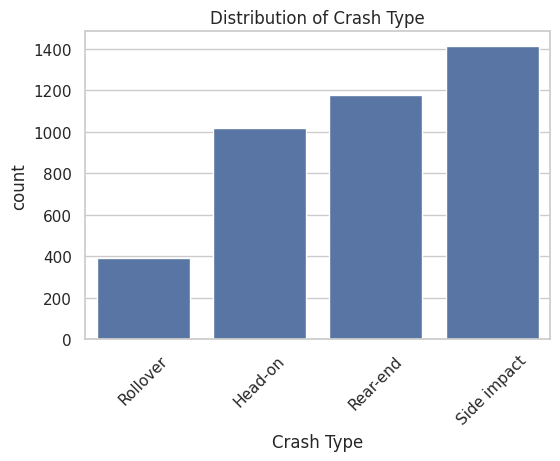

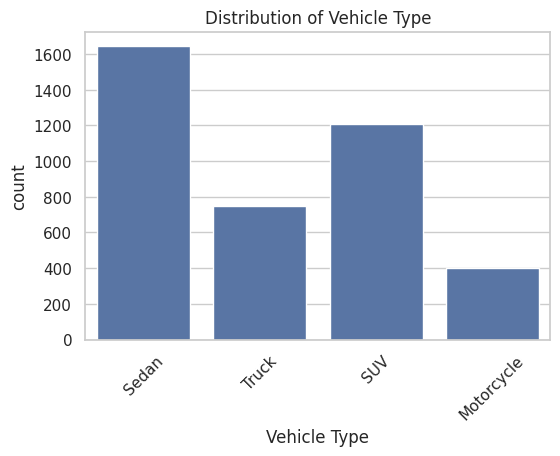

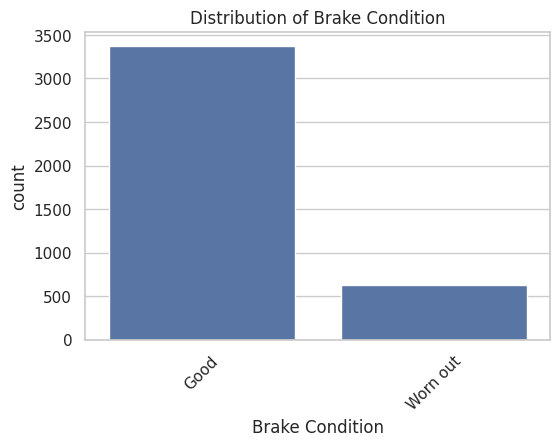

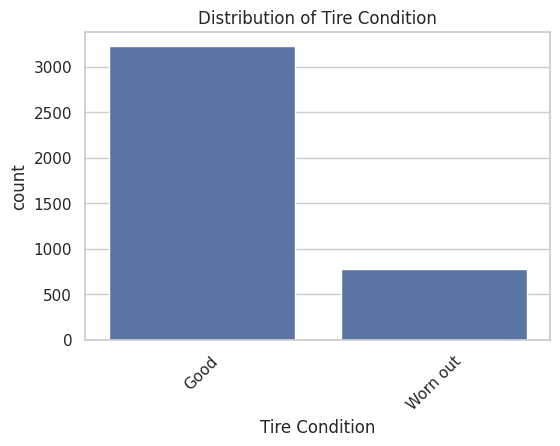

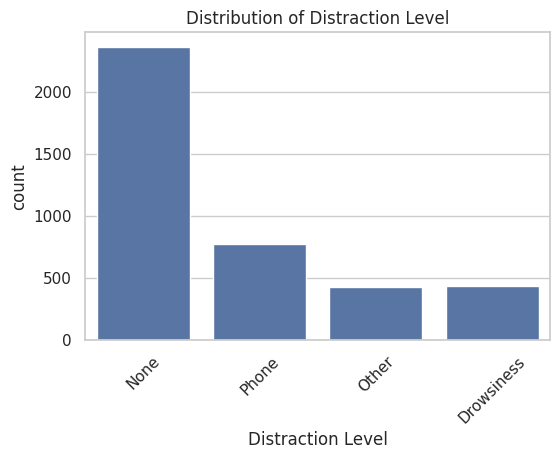

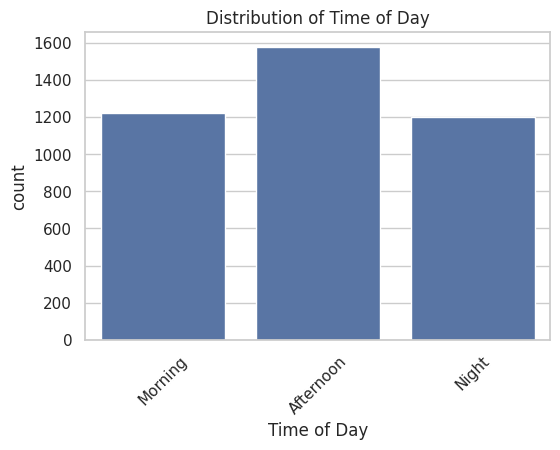

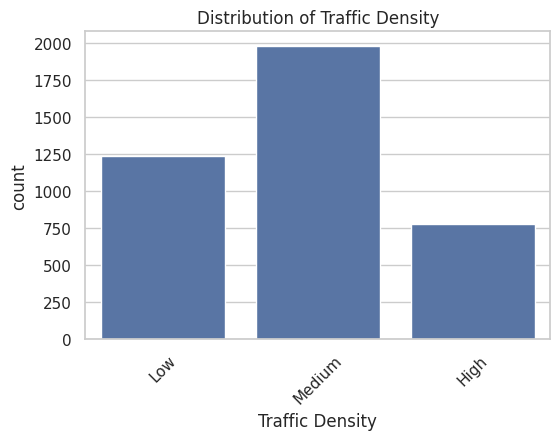

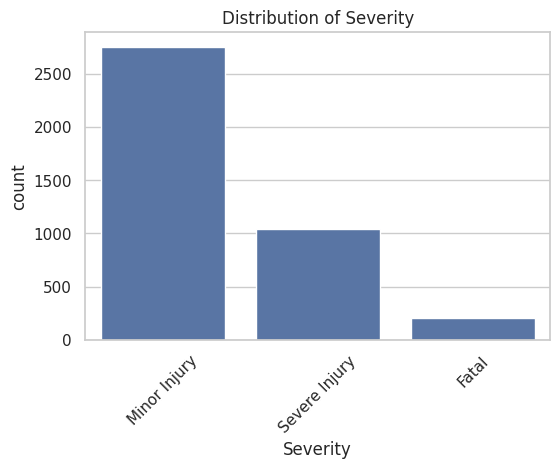

In [74]:
# Select all categorical columns from the training dataset
categorical_cols = train.select_dtypes(include='object').columns

# Loop through each categorical column to visualize its distribution
for col in categorical_cols:

    # Create a new figure for each categorical column
    plt.figure(figsize=(6, 4))

    # Plot the count of each category in the current column
    sns.countplot(x=train[col])

    # Add a title showing which column is being visualized
    plt.title(f"Distribution of {col}")

    # Rotate the x-axis labels to make them easier to read
    plt.xticks(rotation=45)

    # Display the plot
    plt.show()

### Categorical Features Analysis

The categorical features show varied distributions across different categories.

- Features such as **Airbag Deployed** and **Seatbelt Used** are imbalanced, with more cases of airbag deployment and seatbelt usage.
- **Weather Conditions** and **Road Conditions** show that most crashes occur under normal conditions (e.g., clear weather and dry roads).
- **Crash Type** varies, with side impact and rear-end collisions being more frequent.
- **Vehicle Type** and **Traffic Density** also show uneven distributions across categories.
- The **Distraction Level** feature shows that **“None”** is the most common category, meaning that most records had no recorded driver distraction. Among the actual distraction types, phone usage is the most frequent, followed by drowsiness and other distractions.

Overall, categorical features provide meaningful variations that may help in predicting crash severity.

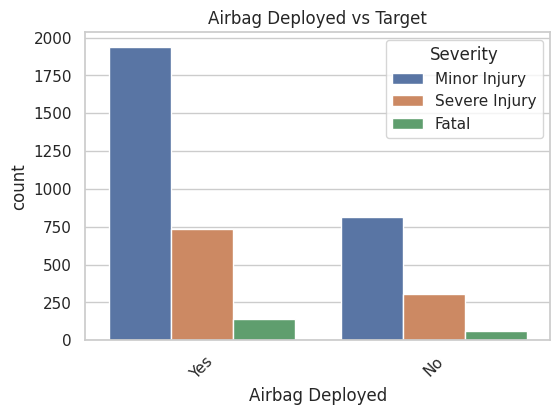

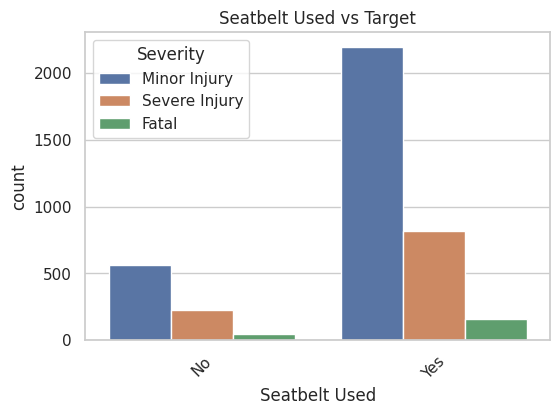

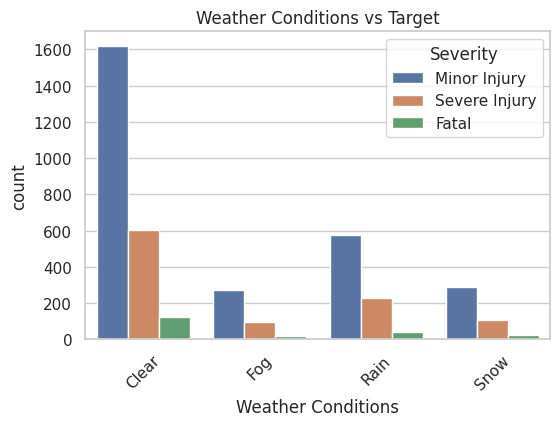

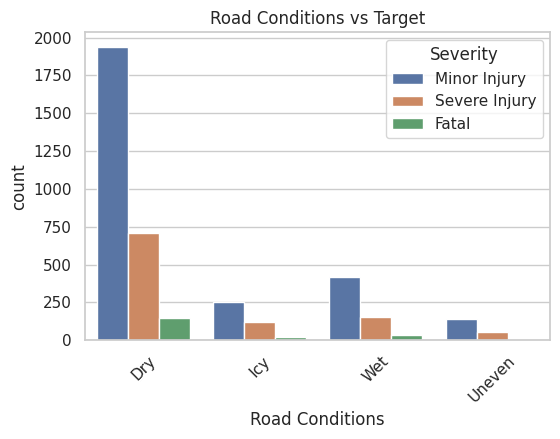

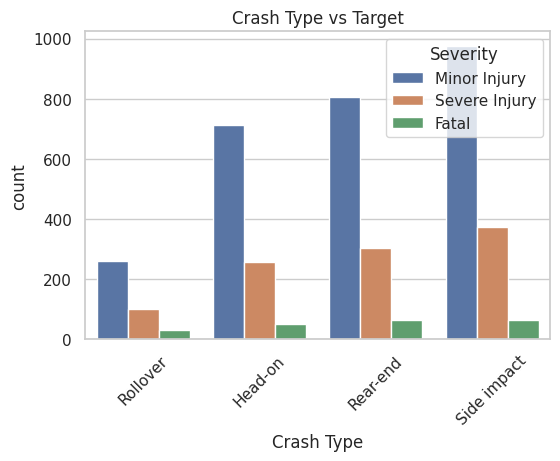

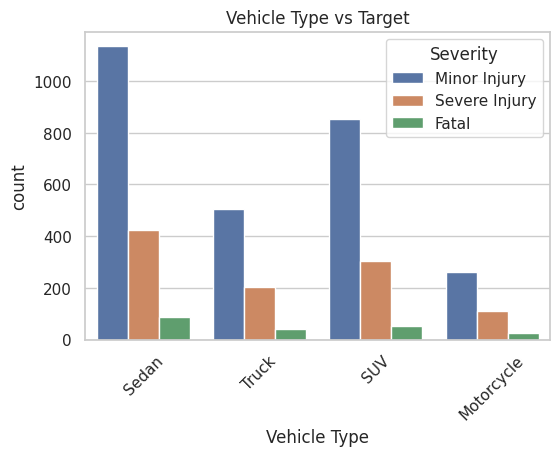

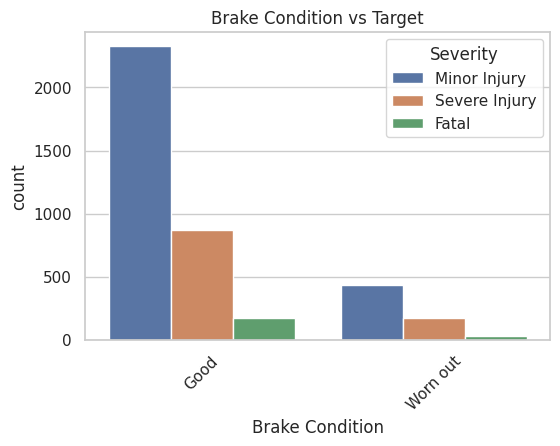

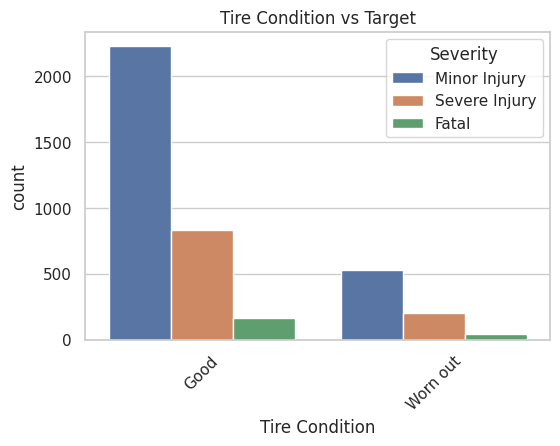

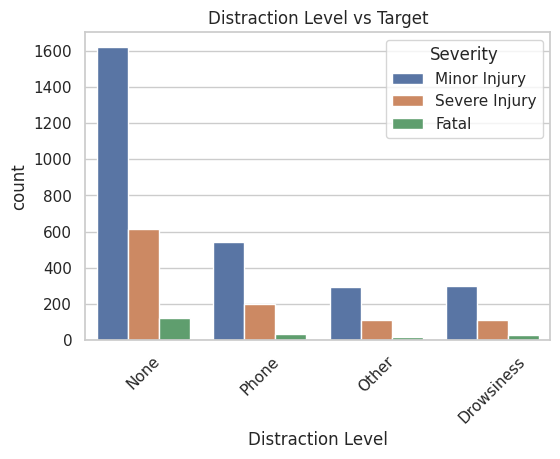

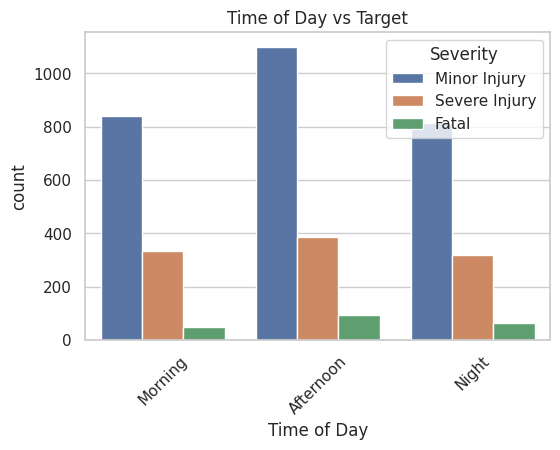

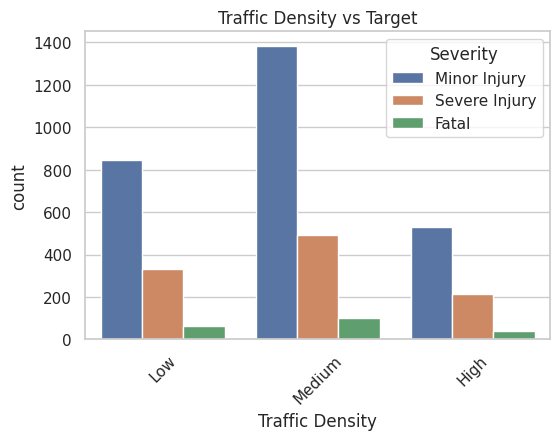

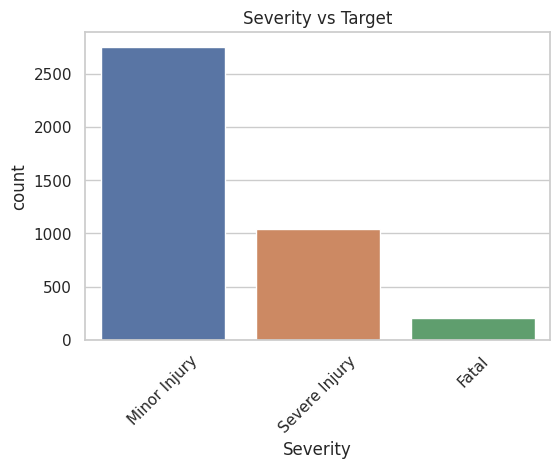

In [75]:
# Loop through each categorical column to compare it with the target variable
for col in categorical_cols:

    # Create a new figure for each categorical feature
    plt.figure(figsize=(6, 4))

    # Plot the count of each category and separate the bars by target class
    # This helps show how each categorical feature is related to the target variable
    sns.countplot(x=train[col], hue=train[target_col])

    # Add a title showing the current categorical column compared with the target
    plt.title(f"{col} vs Target")

    # Rotate the x-axis labels to make them easier to read
    plt.xticks(rotation=45)

    # Display the plot
    plt.show()

## Data Preprocessing

In [44]:
# Separate features and target from the training dataset

X = train.drop('Severity', axis=1)
y = train['Severity']

X.head()

,Crash Speed (km/h),Impact Angle (degrees),Airbag Deployed,Seatbelt Used,Weather Conditions,Road Conditions,Crash Type,Vehicle Type,Vehicle Age (years),Brake Condition,Tire Condition,Driver Age,Driver Experience (years),Alcohol Level (BAC%),Distraction Level,Time of Day,Traffic Density,Visibility Distance (m)
0,182,69,Yes,No,Clear,Dry,Rollover,Sedan,5,Good,Good,23,11,0.025314,None,Morning,Low,213
1,192,73,Yes,No,Clear,Dry,Head-on,Truck,3,Good,Good,29,27,0.002372,Phone,Morning,Medium,426
2,114,77,No,Yes,Clear,Dry,Head-on,Sedan,16,Good,Worn out,73,45,0.000483,None,Morning,Medium,175
3,93,14,No,Yes,Clear,Dry,Rear-end,Truck,14,Worn out,Worn out,27,18,0.176578,None,Afternoon,Medium,82
4,170,96,No,Yes,Clear,Dry,Side impact,SUV,15,Good,Good,70,27,0.065696,Other,Morning,Medium,96


In [45]:
# Check missing values in features

X.isnull().sum().sort_values(ascending=False)

,0
Crash Speed (km/h),0
Impact Angle (degrees),0
Airbag Deployed,0
Seatbelt Used,0
Weather Conditions,0
Road Conditions,0
Crash Type,0
Vehicle Type,0
Vehicle Age (years),0
Brake Condition,0


In [46]:
# Apply one-hot encoding

X = pd.get_dummies(X, drop_first=True)

X.head()

,Crash Speed (km/h),Impact Angle (degrees),Vehicle Age (years),Driver Age,Driver Experience (years),Alcohol Level (BAC%),Visibility Distance (m),Airbag Deployed_Yes,Seatbelt Used_Yes,Weather Conditions_Fog,...,Vehicle Type_Truck,Brake Condition_Worn out,Tire Condition_Worn out,Distraction Level_None,Distraction Level_Other,Distraction Level_Phone,Time of Day_Morning,Time of Day_Night,Traffic Density_Low,Traffic Density_Medium
0,182,69,5,23,11,0.025314,213,True,False,False,...,False,False,False,True,False,False,True,False,True,False
1,192,73,3,29,27,0.002372,426,True,False,False,...,True,False,False,False,False,True,True,False,False,True
2,114,77,16,73,45,0.000483,175,False,True,False,...,False,False,True,True,False,False,True,False,False,True
3,93,14,14,27,18,0.176578,82,False,True,False,...,True,True,True,True,False,False,False,False,False,True
4,170,96,15,70,27,0.065696,96,False,True,False,...,False,False,False,False,True,False,True,False,False,True


### Encoding Categorical Features

Categorical features are converted into numerical format using **One-Hot Encoding**. This allows machine learning models to process the data effectively.

The parameter `drop_first=True` is used to avoid redundancy and reduce multicollinearity.

In [47]:
from sklearn.model_selection import train_test_split

# Split the processed training dataset into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_val.shape

((3200, 30), (800, 30))

### Splitting the Dataset

I split the processed dataset into 80% training and 20% validation using train_test_split. The training set contains 3200 rows and the validation set contains 800 rows, both with 30 encoded features. I used random_state=42 to make the split reproducible, and I used stratify=y because the target variable is imbalanced. Stratification preserves the same class distribution of Severity in both the training and validation sets, which makes the validation evaluation more reliable.

In [76]:
# Import LabelEncoder to convert categorical target labels into numerical values
from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder object
label_encoder = LabelEncoder()

# Fit the encoder on the training target labels and transform them into numbers
y_train_encoded = label_encoder.fit_transform(y_train)

# Transform the validation target labels using the same encoder
# This ensures that the class labels are encoded consistently in both training and validation sets
y_val_encoded = label_encoder.transform(y_val)

In [49]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

import pandas as pd

In [77]:
# Create a Stratified K-Fold cross-validation object
# StratifiedKFold keeps the same class distribution in each fold,
# which is important for imbalanced classification problems
cv = StratifiedKFold(

    # Split the training data into 5 folds
    n_splits=5,

    # Shuffle the data before splitting to make the folds more random
    shuffle=True,

    # Set a random state to make the results reproducible
    random_state=42
)

## Model Training and Evaluation

In [78]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler

In [79]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [80]:
# Create a machine learning pipeline for the K-Nearest Neighbors model
knn_pipeline = Pipeline([

    # Apply random oversampling to balance the target classes in the training data
    ('oversample', RandomOverSampler(random_state=42)),

    # Standardize the feature values so that all features have a similar scale
    # This is important for KNN because it depends on distance calculations
    ('scaler', StandardScaler()),

    # Add the K-Nearest Neighbors classifier as the model
    ('model', KNeighborsClassifier())
])

# Define the hyperparameter grid for KNN
# GridSearchCV will try all combinations of these values
knn_param_grid = {

    # Try different numbers of nearest neighbors
    'model__n_neighbors': list(range(3, 8)),

    # Try two weighting methods:
    # 'uniform' gives equal weight to all neighbors
    # 'distance' gives closer neighbors more influence
    'model__weights': ['uniform', 'distance'],

    # Try two distance metrics:
    # p=1 means Manhattan distance
    # p=2 means Euclidean distance
    'model__p': [1, 2]
}

# Create a GridSearchCV object to find the best KNN hyperparameters
knn_search = GridSearchCV(

    # Use the KNN pipeline defined above
    estimator=knn_pipeline,

    # Use the hyperparameter grid defined above
    param_grid=knn_param_grid,

    # Use accuracy as the evaluation metric during cross-validation
    scoring='accuracy',

    # Use the Stratified K-Fold cross-validation object
    cv=cv,

    # Use all available CPU cores to speed up the search
    n_jobs=-1
)

# Train the KNN model using GridSearchCV on the training data
knn_search.fit(X_train, y_train_encoded)

# Predict the target labels for the validation data using the best KNN model
y_pred_knn = knn_search.predict(X_val)

# Print the best hyperparameter combination found by GridSearchCV
print("Best KNN Parameters:")
print(knn_search.best_params_)

# Print the best average cross-validation accuracy achieved during GridSearchCV
print("\nBest KNN Cross-Validation Accuracy:")
print(knn_search.best_score_)

# Print the validation accuracy of the best KNN model
print("\nKNN Validation Accuracy:")
print(accuracy_score(y_val_encoded, y_pred_knn))

# Print the classification report showing precision, recall, F1-score, and support for each class
print("\nClassification Report:")
print(classification_report(
    y_val_encoded,
    y_pred_knn,
    target_names=label_encoder.classes_
))

Best KNN Parameters:
{'model__n_neighbors': 4, 'model__p': 2, 'model__weights': 'uniform'}

Best KNN Cross-Validation Accuracy:
0.48656249999999995

KNN Validation Accuracy:
0.485

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.07      0.17      0.10        41
 Minor Injury       0.69      0.58      0.63       551
Severe Injury       0.25      0.28      0.27       208

     accuracy                           0.48       800
    macro avg       0.34      0.35      0.33       800
 weighted avg       0.55      0.49      0.51       800



### K-Nearest Neighbors (KNN)

 KNN achieved a cross-validation accuracy of **0.4866** and a validation accuracy of **0.4850**, which shows that its performance is consistent between cross-validation and the validation set. However, the overall accuracy is still low compared to the best-performing model. The classification report shows that KNN performs best on the majority class, **Minor Injury**, but struggles with the minority class, **Fatal**, where both precision and recall are very low. This suggests that KNN is not very suitable for this dataset because it depends on distance calculations, while the dataset contains many one-hot encoded categorical features and an imbalanced target distribution. Therefore, KNN has limited predictive performance for crash severity classification.


In [81]:
# Create a machine learning pipeline for the Decision Tree model
dt_pipeline = Pipeline([

    # Apply random oversampling to balance the target classes in the training data
    ('oversample', RandomOverSampler(random_state=42)),

    # Add the Decision Tree classifier as the model
    # random_state is used to make the results reproducible
    ('model', DecisionTreeClassifier(random_state=42))
])

# Define the hyperparameter grid for the Decision Tree model
# GridSearchCV will test all combinations of these values
dt_param_grid = {

    # Try different splitting criteria
    # 'gini' uses Gini impurity
    # 'entropy' uses information gain
    'model__criterion': ['gini', 'entropy'],

    # Try different maximum tree depths
    # None means the tree can grow until all possible splits are made
    'model__max_depth': [None, 3, 5, 10, 15, 20],

    # Try different minimum numbers of samples required to split an internal node
    'model__min_samples_split': [2, 5, 10],

    # Try different minimum numbers of samples required to be at a leaf node
    'model__min_samples_leaf': [1, 2, 4],

    # Try using no class weighting and balanced class weighting
    # 'balanced' gives more weight to minority classes
    'model__class_weight': [None, 'balanced']
}

# Create a GridSearchCV object to find the best Decision Tree hyperparameters
dt_search = GridSearchCV(

    # Use the Decision Tree pipeline defined above
    estimator=dt_pipeline,

    # Use the hyperparameter grid defined above
    param_grid=dt_param_grid,

    # Use accuracy as the evaluation metric during cross-validation
    scoring='accuracy',

    # Use the Stratified K-Fold cross-validation object
    cv=cv,

    # Use all available CPU cores to speed up the search
    n_jobs=-1
)

# Train the Decision Tree model using GridSearchCV on the training data
dt_search.fit(X_train, y_train_encoded)

# Predict the target labels for the validation data using the best Decision Tree model
y_pred_dt = dt_search.predict(X_val)

# Print the best hyperparameter combination found by GridSearchCV
print("Best Decision Tree Parameters:")
print(dt_search.best_params_)

# Print the best average cross-validation accuracy achieved during GridSearchCV
print("\nBest Decision Tree Cross-Validation Accuracy:")
print(dt_search.best_score_)

# Print the validation accuracy of the best Decision Tree model
print("\nDecision Tree Validation Accuracy:")
print(accuracy_score(y_val_encoded, y_pred_dt))

# Print the classification report showing precision, recall, F1-score, and support for each class
print("\nClassification Report:")
print(classification_report(
    y_val_encoded,
    y_pred_dt,
    target_names=label_encoder.classes_
))

Best Decision Tree Parameters:
{'model__class_weight': None, 'model__criterion': 'entropy', 'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5}

Best Decision Tree Cross-Validation Accuracy:
0.5496874999999999

Decision Tree Validation Accuracy:
0.545

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.08      0.10      0.09        41
 Minor Injury       0.69      0.67      0.68       551
Severe Injury       0.29      0.30      0.29       208

     accuracy                           0.55       800
    macro avg       0.35      0.36      0.35       800
 weighted avg       0.56      0.55      0.55       800



### Decision Tree

The Decision Tree achieved a cross-validation accuracy of 0.5497 and a validation accuracy of 0.5450, showing that its performance is consistent on both cross-validation and unseen validation data. It performed best on the majority class, Minor Injury, but had very weak performance on the Fatal class, where precision, recall, and F1-score were all very low. Compared with KNN, the Decision Tree performed better overall because it can learn decision rules from the features instead of relying on distance calculations. However, it still struggles with the imbalanced target distribution and minority-class prediction, especially for Fatal crashes.

In [82]:
# Create a machine learning pipeline for the Random Forest model
rf_pipeline = Pipeline([

    # Apply random oversampling to balance the target classes in the training data
    ('oversample', RandomOverSampler(random_state=42)),

    # Add the Random Forest classifier as the model
    # random_state is used to make the results reproducible
    ('model', RandomForestClassifier(random_state=42))
])

# Define the hyperparameter grid for the Random Forest model
# GridSearchCV will test all combinations of these values
rf_param_grid = {

    # Use 100 decision trees in the forest
    'model__n_estimators': [100],

    # Use Gini impurity as the splitting criterion
    'model__criterion': ['gini'],

    # Try different maximum depths for the trees
    # None means the trees can grow until all possible splits are made
    'model__max_depth': [None, 10, 20],

    # Try different minimum numbers of samples required to split an internal node
    'model__min_samples_split': [2, 5],

    # Try different minimum numbers of samples required to be at a leaf node
    'model__min_samples_leaf': [1, 2],

    # Try using no class weighting and balanced class weighting
    # 'balanced' gives more weight to minority classes
    'model__class_weight': [None, 'balanced']
}

# Create a GridSearchCV object to find the best Random Forest hyperparameters
rf_search = GridSearchCV(

    # Use the Random Forest pipeline defined above
    estimator=rf_pipeline,

    # Use the hyperparameter grid defined above
    param_grid=rf_param_grid,

    # Use accuracy as the evaluation metric during cross-validation
    scoring='accuracy',

    # Use the Stratified K-Fold cross-validation object
    cv=cv,

    # Use all available CPU cores to speed up the search
    n_jobs=-1
)

# Train the Random Forest model using GridSearchCV on the training data
rf_search.fit(X_train, y_train_encoded)

# Predict the target labels for the validation data using the best Random Forest model
y_pred_rf = rf_search.predict(X_val)

# Print the best hyperparameter combination found by GridSearchCV
print("Best Random Forest Parameters:")
print(rf_search.best_params_)

# Print the best average cross-validation accuracy achieved during GridSearchCV
print("\nBest Random Forest Cross-Validation Accuracy:")
print(rf_search.best_score_)

# Print the validation accuracy of the best Random Forest model
print("\nRandom Forest Validation Accuracy:")
print(accuracy_score(y_val_encoded, y_pred_rf))

# Print the classification report showing precision, recall, F1-score, and support for each class
print("\nClassification Report:")
print(classification_report(
    y_val_encoded,
    y_pred_rf,
    target_names=label_encoder.classes_
))

Best Random Forest Parameters:
{'model__class_weight': None, 'model__criterion': 'gini', 'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Best Random Forest Cross-Validation Accuracy:
0.6809375

Random Forest Validation Accuracy:
0.68

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.69      0.98      0.81       551
Severe Injury       0.29      0.02      0.04       208

     accuracy                           0.68       800
    macro avg       0.33      0.33      0.28       800
 weighted avg       0.55      0.68      0.57       800



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Random Forest

Random Forest achieved the best validation accuracy so far at 0.6800, with a very similar cross-validation accuracy of 0.6809, showing consistent overall performance. However, this high accuracy mainly comes from its strong performance on the majority class, Minor Injury, where recall reached 0.98. The model failed to correctly identify the Fatal class, resulting in 0.00 precision, recall, and F1-score for that class, and it also performed weakly on Severe Injury. Therefore, although Random Forest is the best model in terms of overall accuracy, it is still affected by class imbalance and struggles with minority-class prediction.

In [83]:
# Create a machine learning pipeline for the Logistic Regression model
lr_pipeline = Pipeline([

    # Apply random oversampling to balance the target classes in the training data
    ('oversample', RandomOverSampler(random_state=42)),

    # Standardize the feature values so that all features have a similar scale
    # This is important for Logistic Regression because it is affected by feature scaling
    ('scaler', StandardScaler()),

    # Add the Logistic Regression classifier as the model
    # max_iter=1000 gives the model more iterations to converge
    ('model', LogisticRegression(max_iter=1000))
])

# Define the hyperparameter grid for Logistic Regression
# GridSearchCV will test all combinations of these values
lr_param_grid = {

    # Try different regularization strengths
    # Smaller C means stronger regularization, while larger C means weaker regularization
    'model__C': [0.01, 0.1, 1, 10, 100],

    # Use the lbfgs solver for optimization
    'model__solver': ['lbfgs'],

    # Try using no class weighting and balanced class weighting
    # 'balanced' gives more weight to minority classes
    'model__class_weight': [None, 'balanced']
}

# Create a GridSearchCV object to find the best Logistic Regression hyperparameters
lr_search = GridSearchCV(

    # Use the Logistic Regression pipeline defined above
    estimator=lr_pipeline,

    # Use the hyperparameter grid defined above
    param_grid=lr_param_grid,

    # Use accuracy as the evaluation metric during cross-validation
    scoring='accuracy',

    # Use the Stratified K-Fold cross-validation object
    cv=cv,

    # Use all available CPU cores to speed up the search
    n_jobs=-1
)

# Train the Logistic Regression model using GridSearchCV on the training data
lr_search.fit(X_train, y_train_encoded)

# Predict the target labels for the validation data using the best Logistic Regression model
y_pred_lr = lr_search.predict(X_val)

# Print the best hyperparameter combination found by GridSearchCV
print("Best Logistic Regression Parameters:")
print(lr_search.best_params_)

# Print the best average cross-validation accuracy achieved during GridSearchCV
print("\nBest Logistic Regression Cross-Validation Accuracy:")
print(lr_search.best_score_)

# Print the validation accuracy of the best Logistic Regression model
print("\nLogistic Regression Validation Accuracy:")
print(accuracy_score(y_val_encoded, y_pred_lr))

# Print the classification report showing precision, recall, F1-score, and support for each class
print("\nClassification Report:")
print(classification_report(
    y_val_encoded,
    y_pred_lr,
    target_names=label_encoder.classes_
))

Best Logistic Regression Parameters:
{'model__C': 0.1, 'model__class_weight': None, 'model__solver': 'lbfgs'}

Best Logistic Regression Cross-Validation Accuracy:
0.304375

Logistic Regression Validation Accuracy:
0.35625

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.05      0.32      0.09        41
 Minor Injury       0.72      0.36      0.48       551
Severe Injury       0.27      0.35      0.31       208

     accuracy                           0.36       800
    macro avg       0.35      0.34      0.29       800
 weighted avg       0.57      0.36      0.42       800



### Logistic Regression

Logistic Regression had a low validation accuracy of 0.3563, so it is not the best model in terms of overall performance. One reason is that Logistic Regression uses linear decision boundaries, meaning it works best when the classes can be separated in a mostly linear way. However, crash severity likely depends on non-linear relationships and complex combinations of features, such as crash speed, crash type, seatbelt usage, airbag deployment, and road conditions. Because Logistic Regression cannot capture these complex interactions as well as tree-based models, its accuracy was low. Although it detected more Fatal cases than Random Forest, its Fatal precision was very low, meaning many Fatal predictions were incorrect.

In [84]:
# Create a machine learning pipeline for the Naive Bayes model
nb_pipeline = Pipeline([

    # Apply random oversampling to balance the target classes in the training data
    ('oversample', RandomOverSampler(random_state=42)),

    # Standardize the feature values so that all features have a similar scale
    ('scaler', StandardScaler()),

    # Add the Gaussian Naive Bayes classifier as the model
    ('model', GaussianNB())
])

# Define the hyperparameter grid for Naive Bayes
# GridSearchCV will test different var_smoothing values
nb_param_grid = {

    # var_smoothing adds a small value to variances to improve numerical stability
    'model__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4]
}

# Create a GridSearchCV object to find the best Naive Bayes hyperparameter
nb_search = GridSearchCV(

    # Use the Naive Bayes pipeline defined above
    estimator=nb_pipeline,

    # Use the hyperparameter grid defined above
    param_grid=nb_param_grid,

    # Use accuracy as the evaluation metric during cross-validation
    scoring='accuracy',

    # Use the Stratified K-Fold cross-validation object
    cv=cv,

    # Use all available CPU cores to speed up the search
    n_jobs=-1
)

# Train the Naive Bayes model using GridSearchCV on the training data
nb_search.fit(X_train, y_train_encoded)

# Predict the target labels for the validation data using the best Naive Bayes model
y_pred_nb = nb_search.predict(X_val)

# Print the best hyperparameter value found by GridSearchCV
print("Best Naive Bayes Parameters:")
print(nb_search.best_params_)

# Print the best average cross-validation accuracy achieved during GridSearchCV
print("\nBest Naive Bayes Cross-Validation Accuracy:")
print(nb_search.best_score_)

# Print the validation accuracy of the best Naive Bayes model
print("\nNaive Bayes Validation Accuracy:")
print(accuracy_score(y_val_encoded, y_pred_nb))

# Print the classification report showing precision, recall, F1-score, and support for each class
print("\nClassification Report:")
print(classification_report(
    y_val_encoded,
    y_pred_nb,
    target_names=label_encoder.classes_
))

Best Naive Bayes Parameters:
{'model__var_smoothing': 1e-09}

Best Naive Bayes Cross-Validation Accuracy:
0.3175

Naive Bayes Validation Accuracy:
0.35125

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.04      0.29      0.07        41
 Minor Injury       0.70      0.38      0.49       551
Severe Injury       0.28      0.29      0.29       208

     accuracy                           0.35       800
    macro avg       0.34      0.32      0.28       800
 weighted avg       0.56      0.35      0.42       800



### Naïve Bayes

Naive Bayes achieved a cross-validation accuracy of 0.3175 and a validation accuracy of 0.3513, which indicates weak overall performance. It detected some Fatal cases, shown by a Fatal recall of 0.29, but its Fatal precision was very low at 0.04, meaning most Fatal predictions were incorrect. The model performed poorly because Naive Bayes assumes that features are independent, while crash severity likely depends on combinations of related factors such as speed, crash type, seatbelt usage, and road conditions. Therefore, Naive Bayes was not suitable for this dataset compared with tree-based models.

In [85]:
# Create a DataFrame to compare the performance of all tuned models
model_results = pd.DataFrame({

    # Store the names of the models that were trained and evaluated
    'Model': [
        'KNN',
        'Decision Tree',
        'Random Forest',
        'Logistic Regression',
        'Naive Bayes'
    ],

    # Store the best cross-validation accuracy achieved by each model during GridSearchCV
    'Best CV Accuracy': [
        knn_search.best_score_,
        dt_search.best_score_,
        rf_search.best_score_,
        lr_search.best_score_,
        nb_search.best_score_
    ],

    # Store the validation accuracy of each best model on the validation set
    'Validation Accuracy': [
        accuracy_score(y_val_encoded, y_pred_knn),
        accuracy_score(y_val_encoded, y_pred_dt),
        accuracy_score(y_val_encoded, y_pred_rf),
        accuracy_score(y_val_encoded, y_pred_lr),
        accuracy_score(y_val_encoded, y_pred_nb)
    ],

    # Store the best hyperparameters selected for each model by GridSearchCV
    'Best Parameters': [
        knn_search.best_params_,
        dt_search.best_params_,
        rf_search.best_params_,
        lr_search.best_params_,
        nb_search.best_params_
    ]
})

# Sort the models from highest validation accuracy to lowest validation accuracy
# This makes it easier to identify the best-performing model on the validation set
model_results = model_results.sort_values(
    by='Validation Accuracy',
    ascending=False
)

# Display the final comparison table of model performance
model_results

,Model,Best CV Accuracy,Validation Accuracy,Best Parameters
2,Random Forest,0.680937,0.68000,"{'model__class_weight': None, 'model__criterio..."
1,Decision Tree,0.549687,0.54500,"{'model__class_weight': None, 'model__criterio..."
0,KNN,0.486562,0.48500,"{'model__n_neighbors': 4, 'model__p': 2, 'mode..."
3,Logistic Regression,0.304375,0.35625,"{'model__C': 0.1, 'model__class_weight': None,..."
4,Naive Bayes,0.317500,0.35125,{'model__var_smoothing': 1e-09}


In [59]:
# Load test dataset
test = pd.read_csv('/content/car_crash_test.csv', keep_default_na=False)


In [60]:
# Separate features and true labels
X_test = test.drop('Severity', axis=1)
y_test = test['Severity']

In [61]:
# Encode test labels using the same encoder fitted on the training labels

y_test_encoded = label_encoder.transform(y_test)

In [62]:
# Encode categorical features
X_test = pd.get_dummies(X_test, drop_first=True)

# Align columns with training data
X_test = X_test.reindex(columns=X.columns, fill_value=0)

In [63]:
# Predict on the test dataset using each tuned model

y_test_pred_knn = knn_search.predict(X_test)
y_test_pred_dt = dt_search.predict(X_test)
y_test_pred_rf = rf_search.predict(X_test)
y_test_pred_lr = lr_search.predict(X_test)
y_test_pred_nb = nb_search.predict(X_test)

In [86]:
# Create a DataFrame to compare all tuned models on cross-validation, validation, and test performance
test_results = pd.DataFrame({

    # Store the names of the models that were trained and evaluated
    'Model': [
        'KNN',
        'Decision Tree',
        'Random Forest',
        'Logistic Regression',
        'Naive Bayes'
    ],

    # Store the best cross-validation accuracy achieved by each model during GridSearchCV
    'Best CV Accuracy': [
        knn_search.best_score_,
        dt_search.best_score_,
        rf_search.best_score_,
        lr_search.best_score_,
        nb_search.best_score_
    ],

    # Store the validation accuracy of each model on the validation dataset
    'Validation Accuracy': [
        accuracy_score(y_val_encoded, y_pred_knn),
        accuracy_score(y_val_encoded, y_pred_dt),
        accuracy_score(y_val_encoded, y_pred_rf),
        accuracy_score(y_val_encoded, y_pred_lr),
        accuracy_score(y_val_encoded, y_pred_nb)
    ],

    # Store the test accuracy of each model on the final test dataset
    'Test Accuracy': [
        accuracy_score(y_test_encoded, y_test_pred_knn),
        accuracy_score(y_test_encoded, y_test_pred_dt),
        accuracy_score(y_test_encoded, y_test_pred_rf),
        accuracy_score(y_test_encoded, y_test_pred_lr),
        accuracy_score(y_test_encoded, y_test_pred_nb)
    ],

    # Store the best hyperparameters selected for each model by GridSearchCV
    'Best Parameters': [
        knn_search.best_params_,
        dt_search.best_params_,
        rf_search.best_params_,
        lr_search.best_params_,
        nb_search.best_params_
    ]
})

# Sort the models from highest test accuracy to lowest test accuracy
# This helps identify which model performed best on unseen test data
test_results = test_results.sort_values(
    by='Test Accuracy',
    ascending=False
)

# Display the final comparison table for all tuned models
test_results

,Model,Best CV Accuracy,Validation Accuracy,Test Accuracy,Best Parameters
2,Random Forest,0.680937,0.68000,0.697,"{'model__class_weight': None, 'model__criterio..."
1,Decision Tree,0.549687,0.54500,0.532,"{'model__class_weight': None, 'model__criterio..."
0,KNN,0.486562,0.48500,0.509,"{'model__n_neighbors': 4, 'model__p': 2, 'mode..."
3,Logistic Regression,0.304375,0.35625,0.344,"{'model__C': 0.1, 'model__class_weight': None,..."
4,Naive Bayes,0.317500,0.35125,0.317,{'model__var_smoothing': 1e-09}


In [87]:
# Store the test predictions of each trained model in a dictionary
# The keys are the model names and the values are the predicted labels on the test set
test_predictions = {
    'KNN': y_test_pred_knn,
    'Decision Tree': y_test_pred_dt,
    'Random Forest': y_test_pred_rf,
    'Logistic Regression': y_test_pred_lr,
    'Naive Bayes': y_test_pred_nb
}

# Loop through each model and its corresponding test predictions
for model_name, predictions in test_predictions.items():

    # Print a separator line to make the output easier to read
    print("=" * 60)

    # Print the name of the current model
    print(model_name)

    # Print another separator line
    print("=" * 60)

    # Calculate and print the test accuracy of the current model
    print("Test Accuracy:", accuracy_score(y_test_encoded, predictions))

    # Print the classification report for the current model
    # This includes precision, recall, F1-score, and support for each class
    print("\nClassification Report:")
    print(classification_report(
        y_test_encoded,
        predictions,
        target_names=label_encoder.classes_,

        # Avoid warning messages when a class has no predicted samples
        zero_division=0
    ))

    # Print the confusion matrix for the current model
    # This shows how many samples were correctly and incorrectly classified for each class
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test_encoded, predictions))

    # Print an empty line to separate the results of different models
    print("\n")

KNN
Test Accuracy: 0.509

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.04      0.12      0.06        41
 Minor Injury       0.72      0.59      0.65       710
Severe Injury       0.29      0.33      0.31       249

     accuracy                           0.51      1000
    macro avg       0.35      0.35      0.34      1000
 weighted avg       0.58      0.51      0.54      1000


Confusion Matrix:
[[  5  29   7]
 [ 91 422 197]
 [ 30 137  82]]


Decision Tree
Test Accuracy: 0.532

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.06      0.10      0.08        41
 Minor Injury       0.71      0.65      0.68       710
Severe Injury       0.23      0.26      0.24       249

     accuracy                           0.53      1000
    macro avg       0.33      0.34      0.33      1000
 weighted avg       0.56      0.53      0.55      1000


Confusion Matrix:
[[  4  27  10]
 [ 38 464 208]


The performance of five classification models was compared on the test dataset: KNN, Decision Tree, Random Forest, Logistic Regression, and Naive Bayes.

Random Forest achieved the highest test accuracy with 69.7%. However, its performance was misleading because it mainly predicted the majority class, Minor Injury. It achieved a very high recall for Minor Injury, but it failed to correctly detect the Fatal class, with a recall of 0.00, and performed very poorly on Severe Injury, with a recall of only 0.02.

KNN and Decision Tree achieved lower test accuracies, 50.9% and 53.2% respectively, but they gave more balanced results compared to Random Forest. The Decision Tree model performed better than KNN in terms of overall test accuracy and showed a more reasonable ability to classify the three classes.

Logistic Regression and Naive Bayes had the lowest test accuracies, 34.4% and 31.7%. Although they detected more Fatal cases than Random Forest, their overall classification performance was weak, especially for the majority class.

Overall, the Decision Tree model can be considered the best model for this project. Although Random Forest had the highest accuracy, it was biased toward the majority class and failed to detect important minority classes. Since this is an imbalanced classification problem, accuracy alone is not enough. The Decision Tree model is preferred because it provides a better balance between overall accuracy and performance across different classes.